In [1]:
import pandas as pd
import numpy as np
import duckdb as db

# Import data + convert to parquet

In [26]:
con = db.connect()

con.execute("""
    COPY (
        SELECT *
        FROM read_json_auto(
            'iowa_liquor_sales_2026_1263_rows/**/*.json'
        )
    )
    TO 'liquor.parquet' (FORMAT PARQUET)
""")

df = pd.read_parquet("liquor.parquet")

df.head()

,invoice_id,ordered_on,store_no,store_name,store_address,store_city,store_zip_code,county_fips_code,county_name,category_code,...,item_no,im_desc,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sales_bottles,sales_dollars,sales_liters,sales_gallons
0,INV-903316,2026-01-01,5444,MARSHALL BEER WINE SPIRITS,11 N 3RD AVE,MARSHALLTOWN,50158,19127,MARSHALL,1022200,...,88296,PATRON SILVER,12,750,24.99,37.49,60,2249.40,45.0,11.887740
1,INV-903316,2026-01-01,5444,MARSHALL BEER WINE SPIRITS,11 N 3RD AVE,MARSHALLTOWN,50158,19127,MARSHALL,1082200,...,69947,RUMPLE MINZE PEPPERMINT SCHNAPPS LIQUEUR,12,1000,16.99,25.49,36,917.64,36.0,9.510192
2,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1022200,...,87484,DON JULIO BLANCO,12,375,14.00,22.00,3,67.00,1.0,0.000000
3,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1022200,...,88296,PATRON SILVER,12,750,24.00,37.00,12,449.00,9.0,2.000000
4,INV-903479,2026-01-02,4417,MAVERIK #5066 / ADAIR,109 S 5TH ST,ADAIR,50002,19001,ADAIR,1081300,...,84393,99 WATERMELON PET MINI,1,50,54.00,81.00,1,81.00,0.0,0.000000


# Info + EDA

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952161 entries, 0 to 1952160
Data columns (total 23 columns):
 #   Column               Dtype  
---  ------               -----  
 0   invoice_id           object 
 1   ordered_on           object 
 2   store_no             object 
 3   store_name           object 
 4   store_address        object 
 5   store_city           object 
 6   store_zip_code       object 
 7   county_fips_code     object 
 8   county_name          object 
 9   category_code        object 
 10  category_name        object 
 11  vendor_number        object 
 12  vendor_name          object 
 13  item_no              object 
 14  im_desc              object 
 15  pack                 object 
 16  bottle_volume_ml     int64  
 17  state_bottle_cost    float64
 18  state_bottle_retail  float64
 19  sales_bottles        object 
 20  sales_dollars        float64
 21  sales_liters         float64
 22  sales_gallons        float64
dtypes: float64(5), int64(1), object(

In [28]:
df.describe()

,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sales_dollars,sales_liters,sales_gallons
count,1.952161e+06,1.952161e+06,1.952161e+06,1.952161e+06,1.952161e+06,1.952161e+06
mean,7.510093e+02,1.399817e+01,2.101696e+01,1.647814e+02,8.617866e+00,2.248266e+00
std,5.433100e+02,2.436581e+01,3.654744e+01,6.069239e+02,4.026066e+01,1.063415e+01
min,2.000000e+01,0.000000e+00,1.000000e+00,-3.240000e+03,-1.200000e+02,-3.170064e+01
25%,3.750000e+02,6.000000e+00,9.000000e+00,4.950000e+01,1.000000e+00,1.981290e-01
50%,7.500000e+02,1.000000e+01,1.500000e+01,8.666000e+01,4.500000e+00,1.188774e+00
75%,1.000000e+03,1.650000e+01,2.475000e+01,1.664400e+02,9.000000e+00,2.377548e+00
max,4.500000e+03,3.750000e+03,5.625000e+03,2.608320e+05,1.320000e+04,3.487000e+03


In [29]:
df.isna().sum()

invoice_id                0
ordered_on                0
store_no                  0
store_name                0
store_address             0
store_city                0
store_zip_code            0
county_fips_code       4129
county_name               0
category_code             0
category_name             0
vendor_number             0
vendor_name               0
item_no                   0
im_desc                   0
pack                      0
bottle_volume_ml          0
state_bottle_cost         0
state_bottle_retail       0
sales_bottles             0
sales_dollars             0
sales_liters              0
sales_gallons             0
dtype: int64

- aggregate by store zip code and find bottles sold

        -> where are people ordering? what stores ordering?

- aggregate by ordered on

        -> look at ordered on and what type of alcohol ordered on dates

        -> what seasons have the most orders? what are they ordering? where are they?

- aggregate by category_code?

        -> most commonly bought liquor purchases? who is ordering them? when are they ordering? how much are they buying them for? how much do they order?

In [30]:
df['store_zip_code'].value_counts()
df['store_name'].value_counts()
df['county_name'].value_counts()

county_name
POLK          374636
LINN          165505
SCOTT         119424
BLACK HAWK     98487
JOHNSON        92563
               ...  
ADAMS           1642
DECATUR         1569
RINGGOLD        1125
TAYLOR          1077
DAVIS            850
Name: count, Length: 100, dtype: int64

<Axes: >

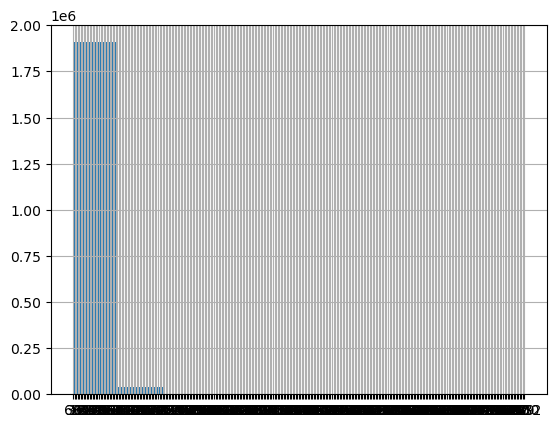

In [ ]:
df[["sales_bottles", "sales_dollars", "sales_liters"]].describe()


# Visualizations

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
corr = df.corr(numeric_only = True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

NameError: name 'df' is not defined

In [6]:
con.execute("""
    DESCRIBE SELECT * FROM 'liquor.parquet'
""").df()

,column_name,column_type,null,key,default,extra
0,invoice_id,VARCHAR,YES,None,None,None
1,ordered_on,DATE,YES,None,None,None
2,store_no,VARCHAR,YES,None,None,None
3,store_name,VARCHAR,YES,None,None,None
4,store_address,VARCHAR,YES,None,None,None
5,store_city,VARCHAR,YES,None,None,None
6,store_zip_code,VARCHAR,YES,None,None,None
7,county_fips_code,VARCHAR,YES,None,None,None
8,county_name,VARCHAR,YES,None,None,None
9,category_code,VARCHAR,YES,None,None,None


In [7]:
zip_sales = con.execute("""
    SELECT
        store_zip_code,
        SUM(CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales,
        COUNT(DISTINCT store_no) AS num_stores
    FROM 'liquor.parquet'
    WHERE store_zip_code IS NOT NULL
    GROUP BY store_zip_code
    ORDER BY total_bottles DESC
""").df()

zip_sales.head(10)

,store_zip_code,total_bottles,total_sales,num_stores
0,50320,732121.0,12528905.45,8
1,51501,663635.0,8627114.78,31
2,50314,637073.0,11153252.09,6
3,52240,581330.0,8045827.97,31
4,52402,527166.0,6969980.57,32
5,50266,523973.0,9890954.61,32
6,52404,435793.0,5067057.46,35
7,52807,417529.0,7351006.81,18
8,50010,394691.0,6240255.85,35
9,50158,374025.0,5064848.88,20


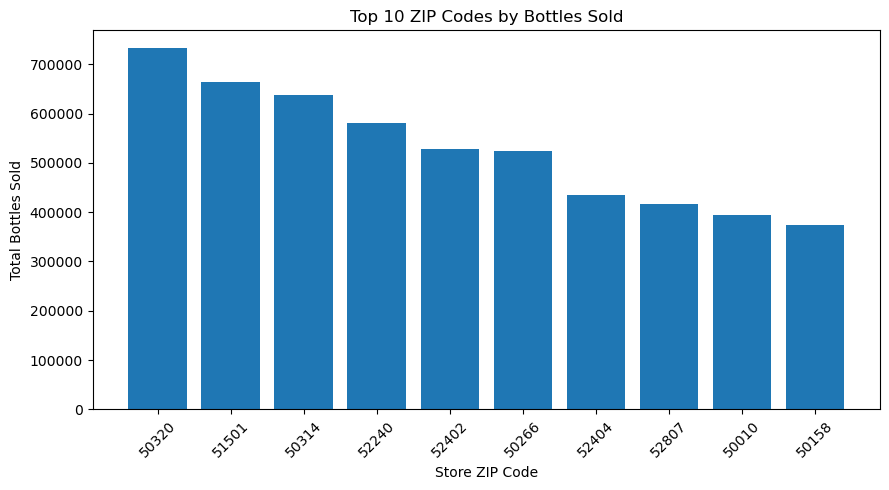

In [20]:
top_zips = zip_sales.head(10)

plt.figure(figsize=(9, 5))

plt.bar(
    top_zips["store_zip_code"].astype(str),
    top_zips["total_bottles"]
)

plt.xlabel("Store ZIP Code")
plt.ylabel("Total Bottles Sold")
plt.title("Top 10 ZIP Codes by Bottles Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
store_sales = con.execute("""
    SELECT
        store_no,
        store_name,
        store_city,
        store_zip_code,
        SUM(CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales
    FROM 'liquor.parquet'
    GROUP BY
        store_no,
        store_name,
        store_city,
        store_zip_code
    ORDER BY total_bottles DESC
""").df()

store_sales.head(10)

,store_no,store_name,store_city,store_zip_code,total_bottles,total_sales
0,2633,HY-VEE #3 / BDI / DES MOINES,DES MOINES,50320,575441.0,11074443.43
1,4829,CENTRAL CITY 2,DES MOINES,50314,457751.0,8986741.38
2,2512,HY-VEE WINE AND SPIRITS #1 (1281) / IOWA CITY,IOWA CITY,52240,290211.0,4329470.68
3,5916,ANOTHER ROUND / DEWITT,DEWITT,52742,255844.0,4968773.87
4,3773,BENZ DISTRIBUTING,CEDAR RAPIDS,52401,205952.0,3988237.55
5,5444,MARSHALL BEER WINE SPIRITS,MARSHALLTOWN,50158,198984.0,2801966.46
6,4312,I-80 LIQUOR / COUNCIL BLUFFS,COUNCIL BLUFFS,51501,174929.0,3083997.58
7,5102,WILKIE LIQUORS,MOUNT VERNON,52314,152061.0,2624490.17
8,2614,HY-VEE #3 FOOD & DRUGSTORE / DAVENPORT,DAVENPORT,52807,138435.0,2442627.77
9,010752,WALL TO WALL WINE AND SPIRITS / WEST DES MOINES,WEST DES MOINES,50266,118741.0,2936251.46


In [10]:
monthly_sales = con.execute("""
    SELECT
        MONTH(ordered_on) AS month,
        SUM(CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales
    FROM 'liquor.parquet'
    GROUP BY month
    ORDER BY month
""").df()

monthly_sales.head(12)

,month,total_bottles,total_sales
0,1,2163052.0,2.856307e+07
1,2,2192141.0,3.013844e+07
2,3,2414969.0,3.391786e+07
3,4,2483580.0,3.367704e+07
4,5,2576531.0,3.472582e+07
5,6,2583023.0,3.565921e+07
6,7,4300242.0,5.889969e+07
7,8,4922788.0,6.609862e+07


In [11]:
category_sales = con.execute("""
    SELECT
        category_code,
        category_name,
        SUM(CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales,
        AVG(state_bottle_retail) AS avg_retail_price
    FROM 'liquor.parquet'
    WHERE category_name IS NOT NULL
    GROUP BY category_code, category_name
    ORDER BY total_bottles DESC
""").df()

category_sales.head(10)

,category_code,category_name,total_bottles,total_sales,avg_retail_price
0,1031100,AMERICAN VODKAS,5190100.0,5.246817e+07,10.522195
1,1081600,WHISKEY LIQUEUR,3704958.0,2.101108e+07,16.576622
2,1012100,CANADIAN WHISKIES,2097502.0,3.374024e+07,17.633021
3,1011200,STRAIGHT BOURBON WHISKIES,1343175.0,3.060705e+07,26.212108
4,1081400,AMERICAN SCHNAPPS,998671.0,7.173488e+06,39.445850
5,1022200,100% AGAVE TEQUILA,964427.0,2.623697e+07,32.420717
6,1062400,SPICED RUM,961769.0,1.500699e+07,14.043768
7,1031200,AMERICAN FLAVORED VODKA,751449.0,8.544198e+06,13.653115
8,1071000,COCKTAILS/RTD,602272.0,7.257979e+06,15.073273
9,1022100,MIXTO TEQUILA,599558.0,8.159181e+06,16.351594


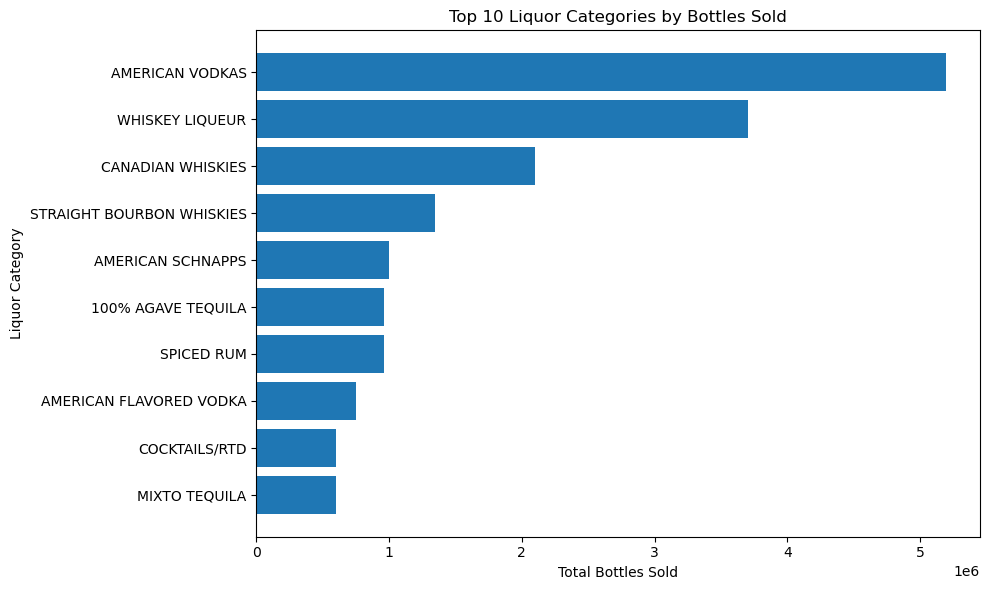

In [14]:
import matplotlib.pyplot as plt

top_categories = category_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories["category_name"],
    top_categories["total_bottles"]
)

plt.xlabel("Total Bottles Sold")
plt.ylabel("Liquor Category")
plt.title("Top 10 Liquor Categories by Bottles Sold")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

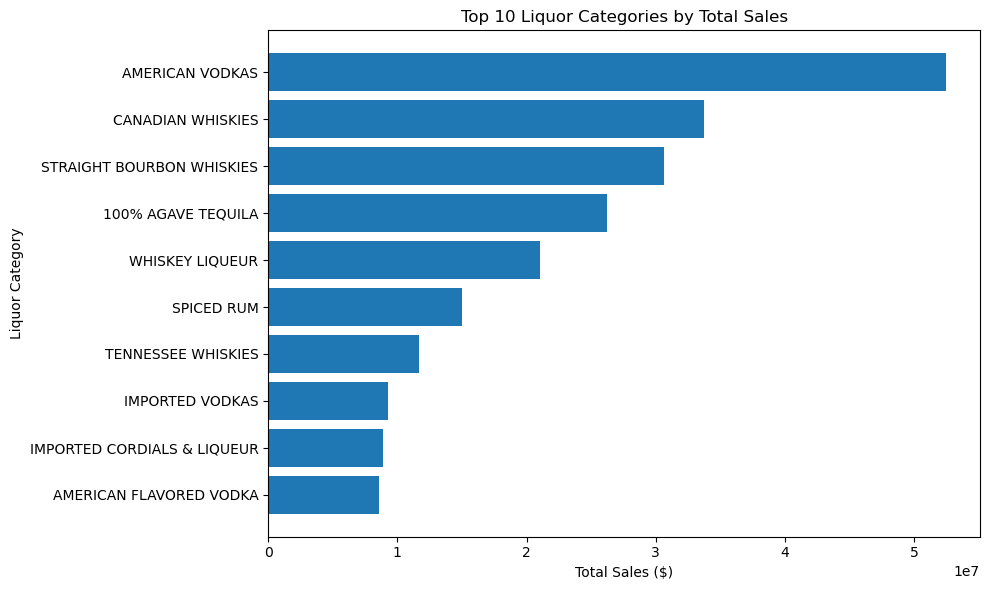

In [15]:
top_categories = (
    category_sales
    .sort_values("total_sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(top_categories["category_name"], top_categories["total_sales"])

plt.xlabel("Total Sales ($)")
plt.ylabel("Liquor Category")
plt.title("Top 10 Liquor Categories by Total Sales")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
season_sales = con.execute("""
    SELECT
        CASE
            WHEN MONTH(ordered_on) IN (12, 1, 2) THEN 'Winter'
            WHEN MONTH(ordered_on) IN (3, 4, 5) THEN 'Spring'
            WHEN MONTH(ordered_on) IN (6, 7, 8) THEN 'Summer'
            ELSE 'Fall'
        END AS season,

        SUM(CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales

    FROM 'liquor.parquet'

    GROUP BY season
    ORDER BY total_bottles DESC
""").df()

season_sales.head(10)

,season,total_bottles,total_sales
0,Summer,11806053.0,1.606575e+08
1,Spring,7475080.0,1.023207e+08
2,Winter,4355193.0,5.870150e+07


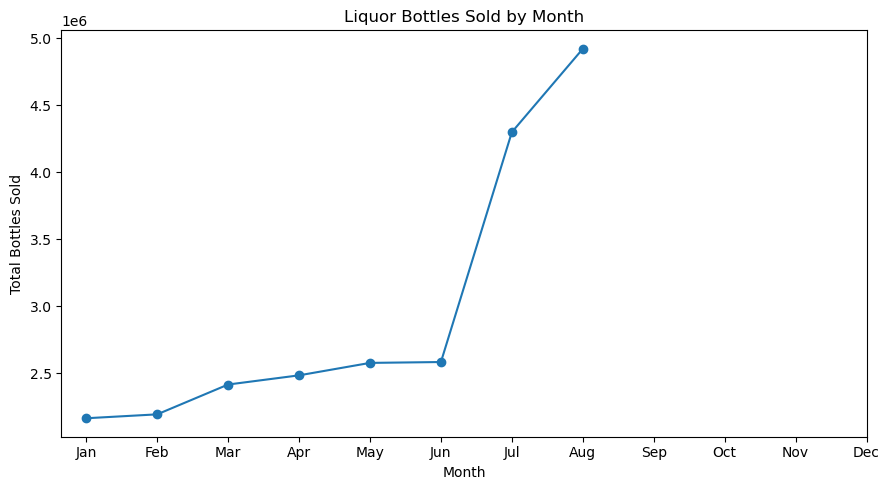

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_sales["month"],
    monthly_sales["total_bottles"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Bottles Sold")
plt.title("Liquor Bottles Sold by Month")

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.tight_layout()
plt.show()

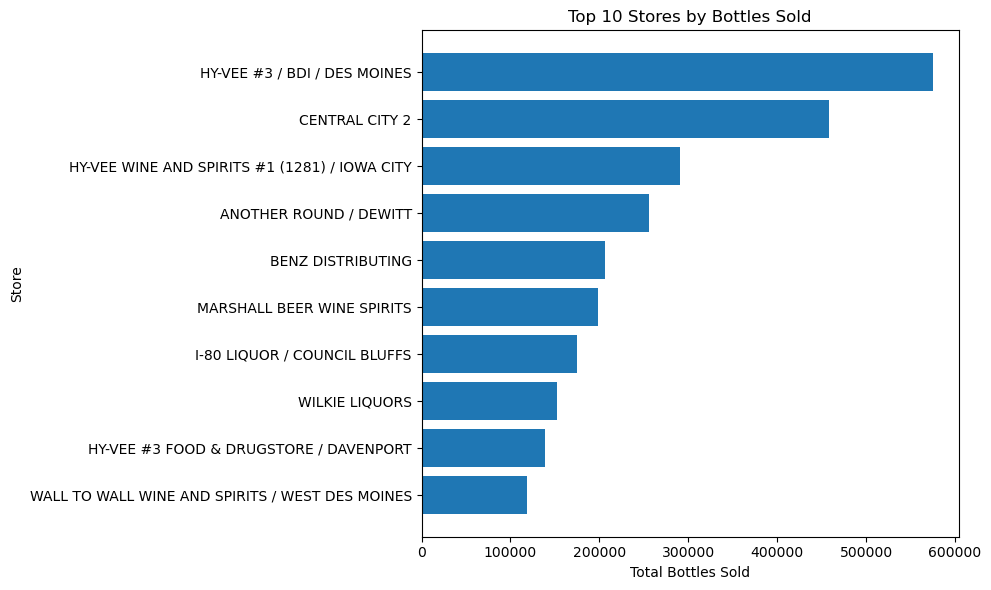

In [17]:
top_stores = store_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_stores["store_name"],
    top_stores["total_bottles"]
)

plt.xlabel("Total Bottles Sold")
plt.ylabel("Store")
plt.title("Top 10 Stores by Bottles Sold")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

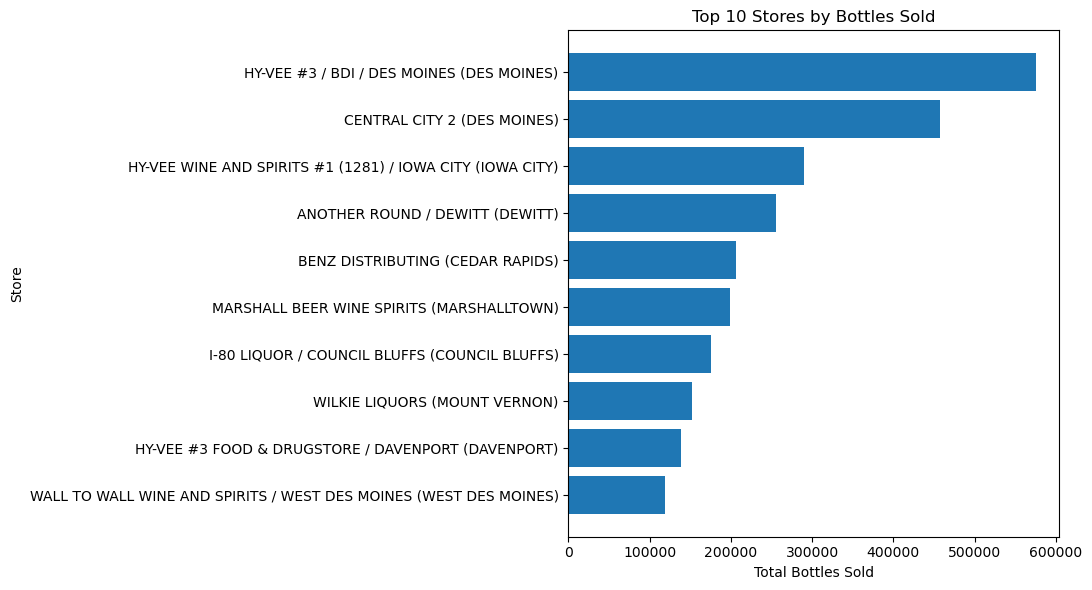

In [18]:
top_stores = store_sales.head(10).copy()

top_stores["store_label"] = (
    top_stores["store_name"] +
    " (" +
    top_stores["store_city"] +
    ")"
)

plt.figure(figsize=(11, 6))
plt.barh(top_stores["store_label"], top_stores["total_bottles"])

plt.xlabel("Total Bottles Sold")
plt.ylabel("Store")
plt.title("Top 10 Stores by Bottles Sold")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
county_sales = con.execute("""
    SELECT
        county_fips_code,
        county_name,
        SUM(CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales
    FROM 'liquor.parquet'
    WHERE county_fips_code IS NOT NULL
    GROUP BY county_fips_code, county_name
    ORDER BY total_bottles DESC
""").df()

county_sales.head(10)

,county_fips_code,county_name,total_bottles,total_sales
0,19153,POLK,5301491.0,74645769.67
1,19113,LINN,2104084.0,28188893.88
2,19163,SCOTT,1638686.0,20325704.37
3,19103,JOHNSON,1265505.0,18874518.02
4,19013,BLACK HAWK,1176732.0,14680631.91
5,19155,POTTAWATTAMIE,969772.0,12433989.38
6,19193,WOODBURY,795911.0,10855171.37
7,19061,DUBUQUE,699440.0,9560102.19
8,19045,CLINTON,552554.0,8322449.65
9,19169,STORY,529303.0,7930553.74


In [24]:
county_sales2 = con.execute("""
    SELECT
        county_fips_code,
        county_name,
        SUM(CAST(sales_bottles AS INTEGER)) AS total_bottles,
        COUNT(DISTINCT store_no) AS num_stores,
        SUM(CAST(sales_bottles AS INTEGER))
            / COUNT(DISTINCT store_no) AS bottles_per_store
    FROM 'liquor.parquet'
    WHERE county_fips_code IS NOT NULL
    GROUP BY county_fips_code, county_name
""").df()

county_sales2.head(10)

,county_fips_code,county_name,total_bottles,num_stores,bottles_per_store
0,19027,CARROLL,151261.0,17,8897.705882
1,19035,CHEROKEE,62880.0,9,6986.666667
2,19039,CLARKE,56940.0,9,6326.666667
3,19067,FLOYD,76042.0,11,6912.909091
4,19147,PALO ALTO,50719.0,9,5635.444444
5,19189,WINNEBAGO,51792.0,8,6474.000000
6,19003,ADAMS,15095.0,3,5031.666667
7,19153,POLK,5301491.0,311,17046.594855
8,19075,GRUNDY,28858.0,8,3607.250000
9,19139,MUSCATINE,299832.0,32,9369.750000


In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_county_500k.zip"

counties = gpd.read_file(url)

# Keep only Iowa
iowa = counties[counties["STATEFP"] == "19"].copy()

iowa.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
34,19,159,00465268,0500000US19159,19159,Ringgold,Ringgold County,IA,Iowa,06,1386922818,8732661,"POLYGON ((-94.47167 40.81254, -94.47166 40.819..."
37,19,163,00465270,0500000US19163,19163,Scott,Scott County,IA,Iowa,06,1186475531,26184354,"POLYGON ((-90.8998 41.5986, -90.89976 41.60069..."
178,19,175,00465276,0500000US19175,19175,Union,Union County,IA,Iowa,06,1097235795,5575854,"POLYGON ((-94.47101 41.04705, -94.47075 41.057..."
441,19,111,00465244,0500000US19111,19111,Lee,Lee County,IA,Iowa,06,1340448555,55266763,"POLYGON ((-91.71879 40.81354, -91.6801 40.8136..."
451,19,063,00465220,0500000US19063,19063,Emmet,Emmet County,IA,Iowa,06,1025349324,17175565,"POLYGON ((-94.9147 43.50022, -94.91457 43.5008..."


In [29]:
county_sales["county_fips_code"] = (
    county_sales["county_fips_code"]
    .astype(str)
    .str.zfill(5)
)

iowa["GEOID"] = iowa["GEOID"].astype(str)

iowa_sales = iowa.merge(
    county_sales,
    left_on="GEOID",
    right_on="county_fips_code",
    how="left"
)

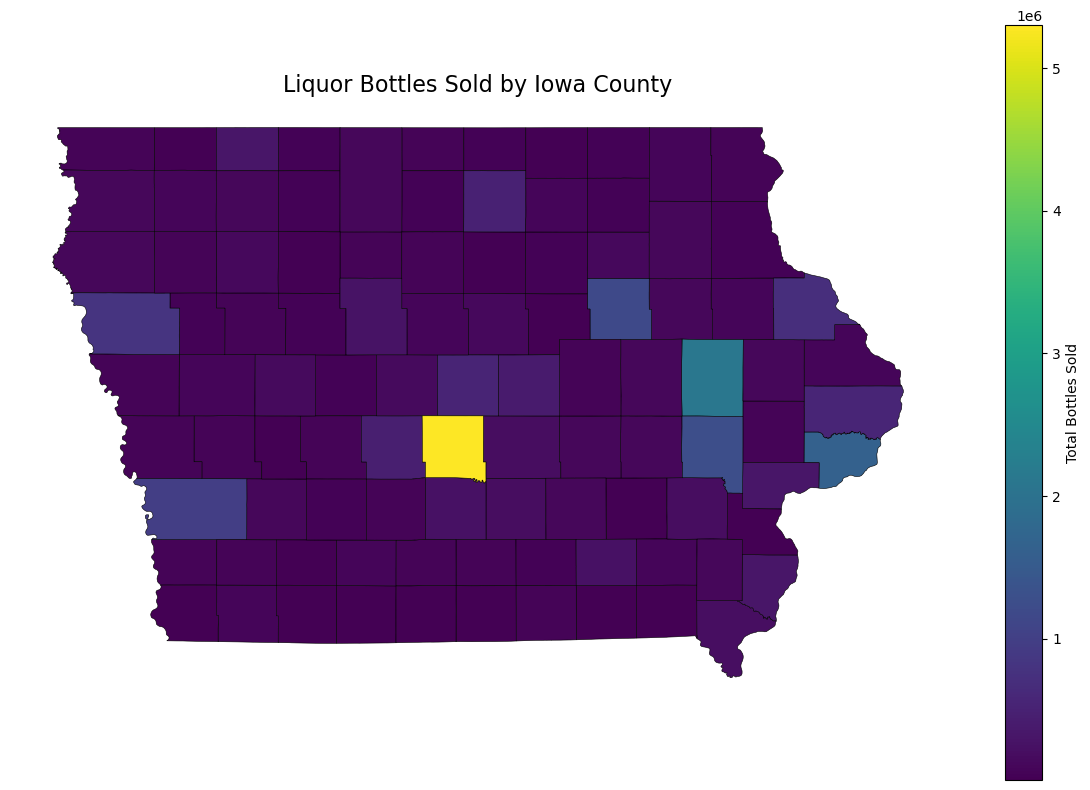

In [30]:
fig, ax = plt.subplots(figsize=(12, 8))

iowa_sales.plot(
    column="total_bottles",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    legend_kwds={
        "label": "Total Bottles Sold"
    }
)

ax.set_title("Liquor Bottles Sold by Iowa County", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()

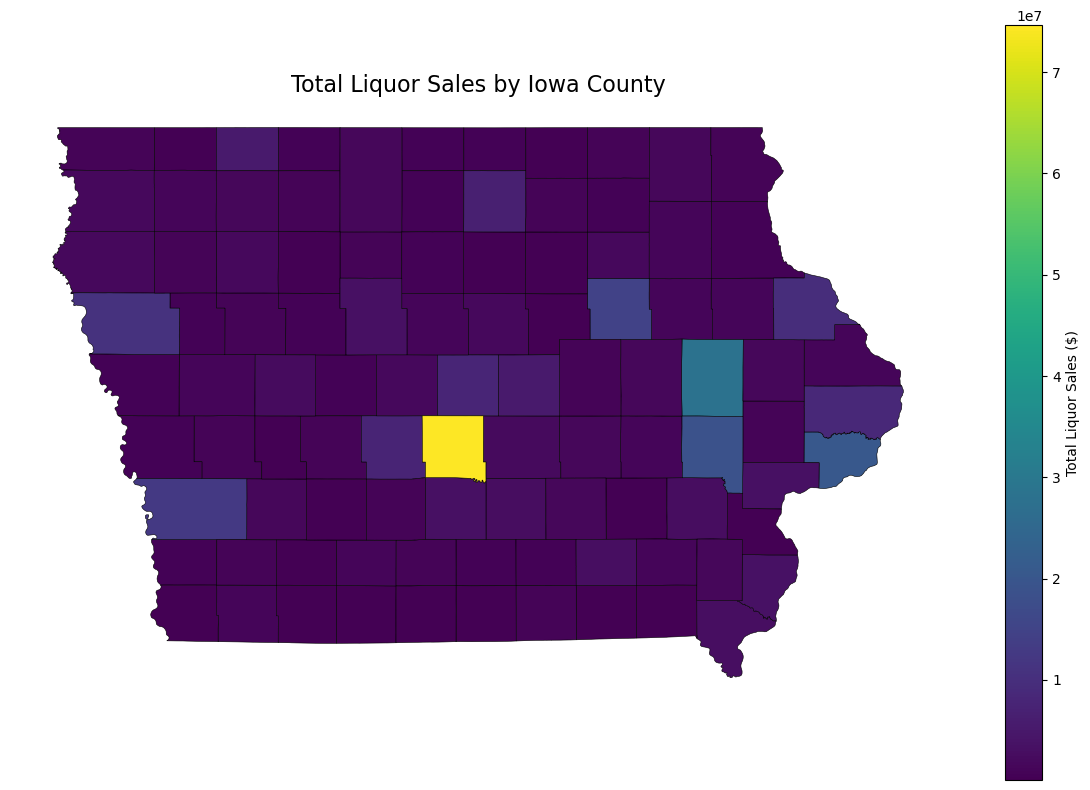

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))

iowa_sales.plot(
    column="total_sales",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    legend_kwds={
        "label": "Total Liquor Sales ($)"
    }
)

ax.set_title("Total Liquor Sales by Iowa County", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()